# 01 · Flight data and anomaly map
Load the SGL flight (Zenodo 4271804) and the `Eastern_395` anomaly map, and check how the measured field matches the map along the track.

Requires data in `data/` (see README).

In [1]:
import os, sys
while not os.path.isdir('magnavlab') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, os.getcwd())
print('repo:', os.getcwd())

repo: /home/wpalka/magnav


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from magnavlab.io import load_flight, load_map, segment_indices
from magnavlab import viz

## Loading and selecting a segment (line 1003.02, ~63 min)

In [3]:
nav = load_flight('data/Flt1003_train.h5')
mag_map = load_map('data/maps/Eastern_395.h5')
sl = segment_indices(nav, 50713.0, 54497.0)[::5]
lat = np.radians(nav.get('lat')[sl]); lon = np.radians(nav.get('lon')[sl])
print(f'samples: {sl.size}, dt={nav.dt:.3f}s')
print(f'map: {mag_map.grid.shape}, alt={mag_map.alt:.0f} m, values {mag_map.grid.min():.0f}..{mag_map.grid.max():.0f} nT')

samples: 7569, dt=0.100s
map: (4881, 6238), alt=395 m, values -1463..7447 nT


## Trajectory over the anomaly map

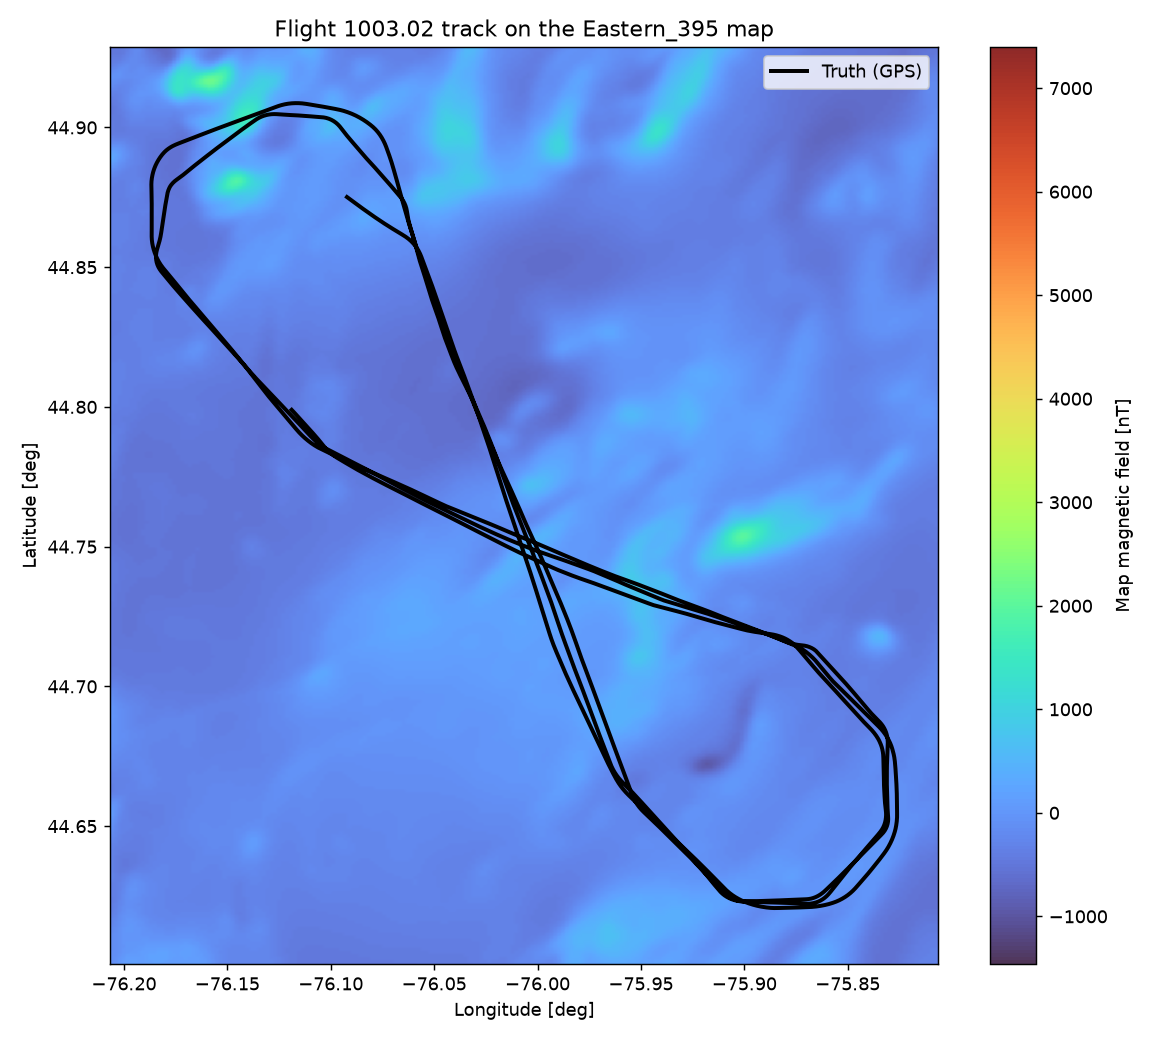

In [4]:
from IPython.display import Image
viz.plot_map_tracks(mag_map, lat, lon, {}, 'outputs/nb01_map.png',
                    title='Flight 1003.02 track on the Eastern_395 map')
Image('outputs/nb01_map.png')

## Measurement (stinger) vs map along the track
Total field `mag_1_c` correlated with the anomaly map (after removing a constant offset).

measurement/map correlation: 0.988


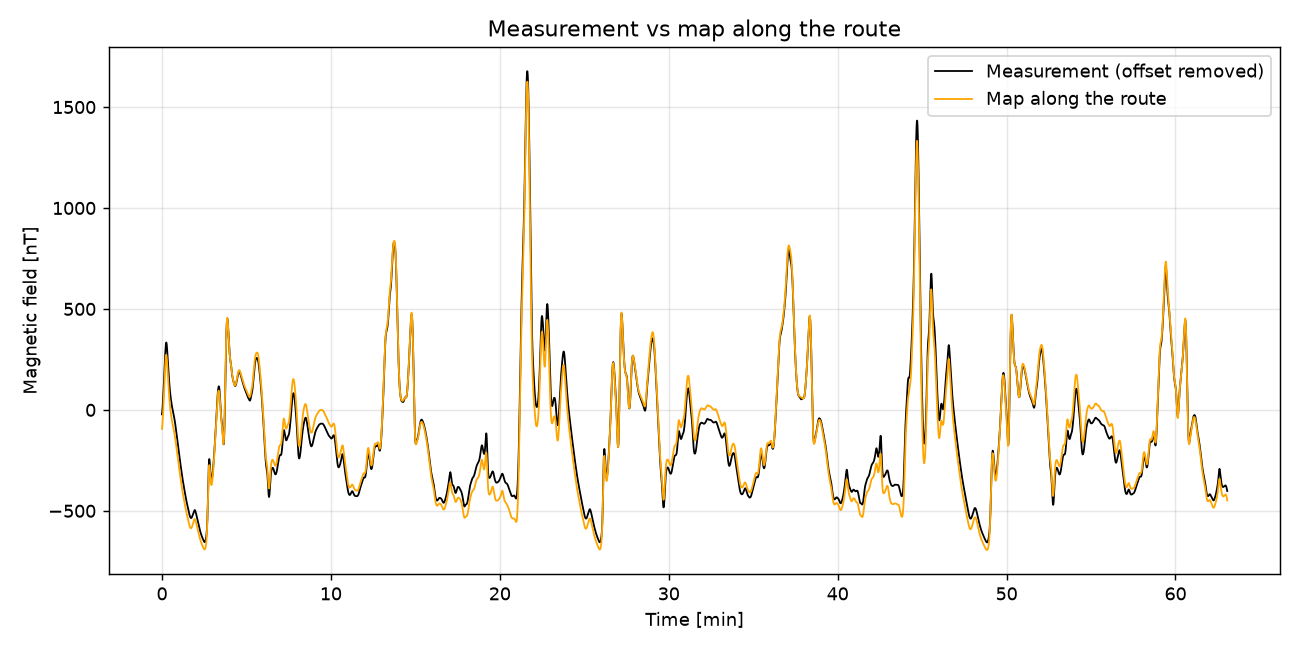

In [5]:
z = nav.get('mag_1_c')[sl] - nav.get('diurnal')[sl]
map_along = mag_map.value(lat, lon)
bias0 = np.median(z - map_along); z = z - bias0
print(f'measurement/map correlation: {np.corrcoef(z, map_along)[0,1]:.3f}')
viz.plot_signal_vs_map(nav.get('tt')[sl], z, map_along, 'outputs/nb01_signal.png')
Image('outputs/nb01_signal.png')